In [1]:
import os
import glob
import numpy as np
import xarray as xr
import rioxarray
from dask.distributed import Client, LocalCluster, progress
from dask.diagnostics import ProgressBar
import dask
import xclim
import xsdba
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

print(xclim.__version__)
print(xsdba.__version__)

0.58.1
0.5.0


In [2]:
# -----------------------------
# Paths to data
# -----------------------------
OBS_PATH = "/home/dafcluster4/Documents/GitHub/TraCE_Sahul/02_data/02_processed/CHELSA/CHELSA_0p05_pr_climatology.nc"
SIM_PATH = "/home/dafcluster4/Documents/GitHub/TraCE_Sahul/02_data/02_processed/TRACE/TraCE_0p05_pr_climatology.nc"
TEST_PATH = "/media/dafcluster4/storage/TraCE_1500_1990CE/1500_1990/out/pr/TraCE_downscaled_1500_1990_concat.nc"

OUTPUT_QDM_TRAINED = "/home/dafcluster4/Documents/GitHub/TraCE_Sahul/python_test/qdm_trained_pr_Sahul.nc"
OUTPUT_ADJUSTED = "/media/dafcluster4/storage/TraCE_1500_1990CE/1500_1990/out/pr/TraCE_22ka_downscaled_pr_1500_1989_qdm.nc"

# chunking: 50 years -> 50 * 12 months
YEARS_PER_CHUNK = 50
MONTHS_PER_CHUNK = YEARS_PER_CHUNK * 12  # = 600

# subset test data to this period
TEST_SUBSET_START = "1500-01-01"
TEST_SUBSET_END = "1989-12-31"

In [ ]:
# -----------------------------
# Dask config (processes avoids GIL issues)
# -----------------------------
# dask.config.set(scheduler="processes")

# Dask local cluster config tuned to 128 cores / 250 GB
N_WORKERS = 5                 # 5 workers × 4 threads = 20 threads
THREADS_PER_WORKER = 4
MEMORY_LIMIT_PER_WORKER = "40.0GB"  # 5 * 40 = 200 GB total

# Shut down any previous cluster in this notebook session
try:
    client.close()
    cluster.close()
except:
    pass

# Start a new cluster
cluster = LocalCluster(
    n_workers=N_WORKERS,
    threads_per_worker=THREADS_PER_WORKER,
    memory_limit=MEMORY_LIMIT_PER_WORKER,
    processes=True,
    dashboard_address=":43051"
)
client = Client(cluster)

client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:43051/status,
Dashboard: http://127.0.0.1:43051/status,Workers: 5
Total threads: 20,Total memory: 186.26 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37899,Workers: 0
Dashboard: http://127.0.0.1:43051/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:35627,Total threads: 4
Dashboard: http://127.0.0.1:35631/status,Memory: 37.25 GiB
Nanny: tcp://127.0.0.1:40149,


2025-09-30 11:20:49,775 - tornado.application - ERROR - Uncaught exception GET /status/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='127.0.0.1:43051', method='GET', uri='/status/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/home/dafcluster4/miniconda3/envs/xclim_stable/lib/python3.13/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
  File "/home/dafcluster4/miniconda3/envs/xclim_stable/lib/python3.13/site-packages/tornado/web.py", line 3375, in wrapper
    return method(self, *args, **kwargs)
  File "/home/dafcluster4/miniconda3/envs/xclim_stable/lib/python3.13/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app with a larger value for --session-token-expiration if necessary")
bokeh.protocol.exceptions.ProtocolError: Token is expired. Configure the app with a larger value

In [4]:
# -----------------------------
# Open small climatologies (obs, sim) with Dask
# -----------------------------
print("Opening climatology files (lazy, with dask chunks)...")
obs = xr.open_dataset(OBS_PATH, decode_times=False, chunks={"time": -1})["pr"]
obs.attrs["units"] = "kg m-2 s-1"

sim = xr.open_dataset(SIM_PATH, decode_times=False, chunks={"time": -1})["pr"]
sim.attrs["units"] = "kg m-2 s-1"

# Ensure time coordinates are months Jan-Dec (climatologies)
months_clim = xr.date_range(
    start="1980-01-01", end="1989-12-31", freq="ME", calendar="noleap", use_cftime=True
)
obs = obs.assign_coords(time=months_clim)
sim = sim.assign_coords(time=months_clim)

# Normalize name of lat/lon if needed
if "longitude" in obs.coords: obs = obs.rename({"longitude": "lon"})
if "latitude" in obs.coords: obs = obs.rename({"latitude": "lat"})
if "longitude" in sim.coords: sim = sim.rename({"longitude": "lon"})
if "latitude" in sim.coords: sim = sim.rename({"latitude": "lat"})

obs = xclim.units.convert_units_to(obs, "mm/d", context="hydro")
sim = xclim.units.convert_units_to(sim, "mm/d", context="hydro")
print("obs:", obs)
print("sim:", sim)

Opening climatology files (lazy, with dask chunks)...
obs: <xarray.DataArray 'pr' (time: 120, lat: 1276, lon: 1126)> Size: 690MB
dask.array<mul, shape=(120, 1276, 1126), dtype=float32, chunksize=(120, 1276, 1126), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 9kB 105.0 105.0 105.1 105.1 ... 161.2 161.2 161.2
  * lat      (lat) float64 10kB 11.25 11.2 11.15 11.1 ... -52.4 -52.45 -52.5
  * time     (time) object 960B 1980-01-31 00:00:00 ... 1989-12-31 00:00:00
Attributes:
    units:         mm d-1
    long_name:     precipitation
    grid_mapping:  crs
sim: <xarray.DataArray 'pr' (time: 120, lat: 1276, lon: 1126)> Size: 690MB
dask.array<mul, shape=(120, 1276, 1126), dtype=float32, chunksize=(120, 1276, 1126), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 9kB 105.0 105.0 105.1 105.1 ... 161.2 161.2 161.2
  * lat      (lat) float64 10kB 11.25 11.2 11.15 11.1 ... -52.4 -52.45 -52.5
  * time     (time) object 960B 1980-01-31 00:00:00 ... 1989-12-31 00:00

In [5]:
# -----------------------------
# Open large simulated dataset with Dask and subset to 1950-1989
# -----------------------------
print("Opening large test dataset (lazy) and subsetting to 1950-01 -> 1989-12 ...")
downTrace = xr.open_dataset(TEST_PATH, decode_times=False, chunks={"time": MONTHS_PER_CHUNK})["pr"]
downTrace = xclim.units.convert_units_to(downTrace, "mm/d", context="hydro")

# assign full time coords then subset
months_full = xr.date_range(
    start="1500-01-01", end="1989-12-31", freq="ME", calendar="noleap", use_cftime=True
)
downTrace = downTrace.assign_coords(time=months_full)

# subset to requested window
downTrace = downTrace.sel(time=slice(TEST_SUBSET_START, TEST_SUBSET_END))
print("downTrace (subset):", downTrace)
print("downTrace size (months):", downTrace.sizes.get("time"))
print("downTrace units:", downTrace.attrs['units'])

Opening large test dataset (lazy) and subsetting to 1950-01 -> 1989-12 ...
downTrace (subset): <xarray.DataArray 'pr' (time: 5880, lat: 1275, lon: 1125)> Size: 34GB
dask.array<mul, shape=(5880, 1275, 1125), dtype=float32, chunksize=(600, 1275, 1125), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 9kB 105.0 105.1 105.1 105.2 ... 161.1 161.2 161.2
  * lat      (lat) float64 10kB -52.47 -52.42 -52.37 ... 11.13 11.18 11.23
  * time     (time) object 47kB 1500-01-31 00:00:00 ... 1989-12-31 00:00:00
Attributes:
    units:          mm d-1
    standard_name:  lwe_precipitation_rate
downTrace size (months): 5880
downTrace units: mm d-1


In [6]:
# -----------------------------
# Assign CRS (rioxarray) - ensure arrays can be reprojected if needed
# -----------------------------
print("Writing CRS (EPSG:4326) to DataArrays (lazy metadata only)...")
obs = obs.rio.write_crs("EPSG:4326")
sim = sim.rio.write_crs("EPSG:4326")
downTrace = downTrace.rio.write_crs("EPSG:4326")

# -----------------------------
# Reproject obs/sim to grid of downTrace
# -----------------------------
# rioxarray needs x/y names for reproject; create x/y copies for the operation
print("Preparing names for reprojection (rioxarray expects x/y)...")
obs_xy = obs.rename({"lat": "y", "lon": "x"})
sim_xy = sim.rename({"lat": "y", "lon": "x"})
downTrace_xy = downTrace.rename({"lat": "y", "lon": "x"})

print("Reprojecting obs and sim to match downTrace grid...")
# reproject_match returns a lazily reprojected DataArray (but may trigger some work)
obs_xy = obs_xy.rio.reproject_match(downTrace_xy)
sim_xy = sim_xy.rio.reproject_match(downTrace_xy)

# Rename back to lat/lon
obs = obs_xy.rename({"y": "lat", "x": "lon"})
sim = sim_xy.rename({"y": "lat", "x": "lon"})
downTrace = downTrace_xy.rename({"y": "lat", "x": "lon"})

Writing CRS (EPSG:4326) to DataArrays (lazy metadata only)...
Preparing names for reprojection (rioxarray expects x/y)...
Reprojecting obs and sim to match downTrace grid...


In [7]:
# -----------------------------
# Rechunk datasets to 50-year time chunks and reasonable spatial chunks
# -----------------------------
print("Calculating dynamic lat/lon chunk sizes...")
# suggested splits: approx 5 splits along each spatial axis (tunable)
n_spatial_splits = 5
lat_len = downTrace.sizes["lat"]
lon_len = downTrace.sizes["lon"]
lat_chunk = max(1, lat_len // n_spatial_splits)
lon_chunk = max(1, lon_len // n_spatial_splits)

print(f"Using chunk sizes -> time: {MONTHS_PER_CHUNK}, lat: {lat_chunk}, lon: {lon_chunk}")

obs = obs.chunk({"time": -1, "lat": lat_chunk, "lon": lon_chunk})
sim = sim.chunk({"time": -1, "lat": lat_chunk, "lon": lon_chunk})
downTrace = downTrace.chunk({"time": MONTHS_PER_CHUNK, "lat": lat_chunk, "lon": lon_chunk})

# Print chunk info for sanity
print("Chunks (obs):", obs.chunks)
print("Chunks (sim):", sim.chunks)
print("Chunks (downTrace):", downTrace.chunks)

Calculating dynamic lat/lon chunk sizes...
Using chunk sizes -> time: 600, lat: 255, lon: 225
Chunks (obs): ((120,), (255, 255, 255, 255, 255), (225, 225, 225, 225, 225))
Chunks (sim): ((120,), (255, 255, 255, 255, 255), (225, 225, 225, 225, 225))
Chunks (downTrace): ((600, 600, 600, 600, 600, 600, 600, 600, 600, 480), (255, 255, 255, 255, 255), (225, 225, 225, 225, 225))


In [8]:
# -----------------------------
# Utility: bbox printer (no heavy compute)
# -----------------------------
def print_bbox(da, name="DataArray"):
    # we call .values on coords only (small)
    lat_vals = xr.DataArray(da["lat"]).values
    lon_vals = xr.DataArray(da["lon"]).values
    lat_min, lat_max = float(np.nanmin(lat_vals)), float(np.nanmax(lat_vals))
    lon_min, lon_max = float(np.nanmin(lon_vals)), float(np.nanmax(lon_vals))
    print(f"{name} bounding box:")
    print(f"  lat: {lat_min} → {lat_max}")
    print(f"  lon: {lon_min} → {lon_max}")
    print()

print_bbox(obs, "obs")
print_bbox(sim, "sim")
print_bbox(downTrace, "downTrace (subset)")

obs bounding box:
  lat: -52.474999999999994 → 11.225000000000009
  lon: 105.025 → 161.225

sim bounding box:
  lat: -52.474999999999994 → 11.225000000000009
  lon: 105.025 → 161.225

downTrace (subset) bounding box:
  lat: -52.474999999999994 → 11.225000000000009
  lon: 105.025 → 161.225



In [10]:
# -----------------------------
# Train (or load existing) QDM (xsdba) using climatologies
# -----------------------------

if os.path.exists(OUTPUT_QDM_TRAINED):
    print(f"Found existing trained QDM: {OUTPUT_QDM_TRAINED}")
    ds = xr.open_dataset(OUTPUT_QDM_TRAINED).load()
    qdm = xsdba.adjustment.QuantileDeltaMapping.from_dataset(ds)
    ds.close()  
    print(qdm.ds)  
else:
    print("Training QDM...")
    qdm = xsdba.adjustment.QuantileDeltaMapping.train(
        obs, sim, nquantiles=101, kind="*", group="time.month"
    )

    print("QDM trained; dataset summary:")
    print(qdm.ds)

    # Save trained QDM to NetCDF
    print(f"Saving trained QDM to {OUTPUT_QDM_TRAINED} ...")
    with ProgressBar():
        qdm.ds.to_netcdf(OUTPUT_QDM_TRAINED, compute=True)
    print("QDM saved.")

Found existing trained QDM: /home/dafcluster4/Documents/GitHub/TraCE_Sahul/python_test/qdm_trained_pr_Sahul.nc
<xarray.Dataset> Size: 14GB
Dimensions:    (lat: 1275, lon: 1125, month: 12, quantiles: 101)
Coordinates:
  * lat        (lat) float64 10kB -52.47 -52.42 -52.37 ... 11.13 11.18 11.23
  * lon        (lon) float64 9kB 105.0 105.1 105.1 105.2 ... 161.1 161.2 161.2
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * quantiles  (quantiles) float32 404B 0.00495 0.01485 0.02475 ... 0.9851 0.995
    crs        int64 8B 0
Data variables:
    hist_q     (lat, lon, month, quantiles) float32 7GB 1.224 1.224 ... 9.36
    af         (lat, lon, month, quantiles) float32 7GB 0.734 0.7389 ... 1.076
Attributes:
    _xsdba_adjustment:  {"py/object": "xsdba.adjustment.QuantileDeltaMapping"...
    adj_params:         QuantileDeltaMapping(group=Grouper(name='time.month')...


In [ ]:
# # -----------------------------
# # Apply QDM to full dataset in 50-year windows
# # -----------------------------

# # Generate 50-year windows from 1500–1989
# years = list(range(1500, 1990, 50))
# windows = [(y, min(y + 50, 1990)) for y in years]  # last window may be shorter

# for start, end in reversed(windows):

#     print(f"Processing {start}-{end-1} ...")
#     out_file = f"/media/dafcluster4/storage/TraCE_1500_1990CE/1500_1990/out/pr/qdm_adj_pr_{start}_{end-1}.nc"

#     if os.path.exists(out_file):
#         print(f"File {out_file} already exists, skipping...")
#         continue

#     subset = downTrace.sel(time=slice(f"{start}-01", f"{end-1}-12"))

#     # Persist to distribute across workers
#     print("Persisting subset data across workers...")
#     subset = subset.persist()

#     # Apply QDM
#     adjTest = qdm.adjust(subset, extrapolation="constant", interp="linear")
#     adjTest = adjTest.transpose("time", "lat", "lon")

#     # Convert to dataset if needed
#     if isinstance(adjTest, xr.DataArray):
#         ds_out = adjTest.to_dataset(name="pr")
#     else:
#         ds_out = adjTest.ds if hasattr(adjTest, "ds") else adjTest

#     # Compression/chunk encoding for NetCDF
#     encoding = {}
#     for v, da in ds_out.data_vars.items():
#         enc = {"zlib": True, "complevel": 4, "shuffle": True}
#         chunks = []
#         for dim in da.dims:
#             if dim == "time":
#                 chunks.append(min(MONTHS_PER_CHUNK, da.sizes[dim]))
#             elif dim == "lat":
#                 chunks.append(min(lat_chunk, da.sizes[dim]))
#             elif dim == "lon":
#                 chunks.append(min(lon_chunk, da.sizes[dim]))
#             else:
#                 continue
#         if chunks:
#             enc["chunksizes"] = tuple(chunks)
#         encoding[v] = enc

#     # Write out slice
#     print(f"Writing adjusted dataset to {out_file} ...")
#     with ProgressBar():
#         ds_out.to_netcdf(
#             out_file,
#             compute=True,
#             format="NETCDF4",
#             encoding=encoding,
#             engine="netcdf4"  # or "netcdf4"
#         )

# print("All 50-year windows processed. Done.")

Processing 1500-1549 ...
<xarray.DataArray 'pr' (time: 600, lat: 1275, lon: 1125)> Size: 3GB
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [0.79999495, 0.79999495, 0.79999495, ...,        nan,
                nan,        nan],
        [0.79999495, 0.79999495, 0.79999495, ...,        nan,
                nan,        nan],
        [0.79999495, 0.79999495, 0.79999495, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [9.699939  , 9.7

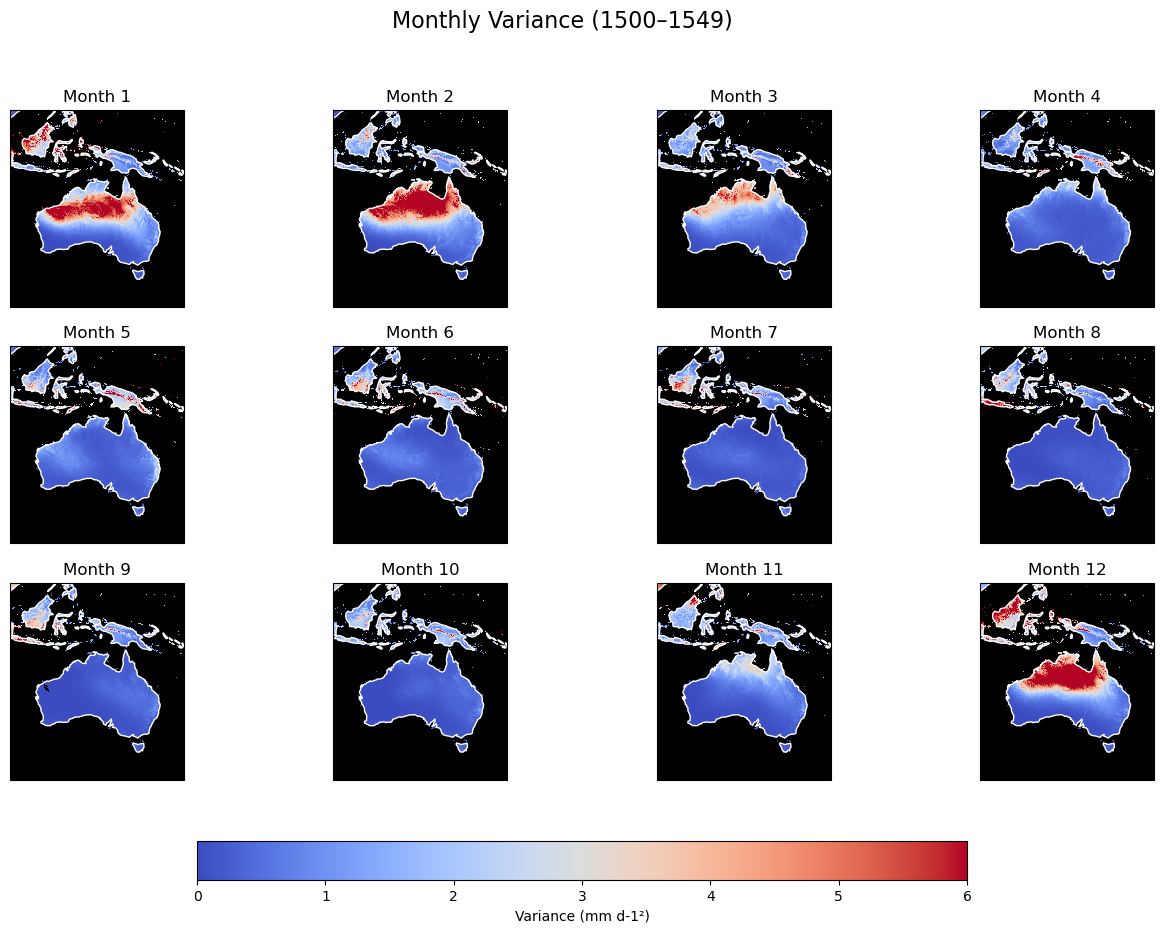

In [ ]:
# -----------------------------
# Apply QDM to first 50-year window only (1500-1549)
# -----------------------------

# Generate 50-year windows from 1500–1989
years = list(range(1500, 1990, 50))
windows = [(y, min(y + 50, 1990)) for y in years]  # last window may be shorter

# Just grab the last window
start, end = windows[0]
print(f"Processing {start}-{end-1} ...")

# # read in training data
# ds = xr.open_dataset(OUTPUT_QDM_TRAINED).load()
# qdm = xsdba.adjustment.QuantileDeltaMapping.from_dataset(ds)
# ds.close()
# print(qdm.ds)

# read in the downTrace data
subset = downTrace.sel(time=slice(f"{start}-01", f"{end-1}-12"))
subset = xclim.units.convert_units_to(subset, "mm/d", context="hydro").compute()
print(subset)

# Check for variance
# Calculate variance across time
monthly_var = subset.groupby("time.month").var(dim="time").compute()
# Mask out zero variance (treat it as missing)
monthly_var = monthly_var.where(monthly_var != 0)
print(monthly_var)

# Set up a 3x4 grid of subplots
fig, axes = plt.subplots(3, 4, figsize=(16, 10), subplot_kw={"projection": ccrs.PlateCarree()})
axes = axes.ravel()

# colormap setup
cmap = plt.cm.coolwarm.copy()
cmap.set_bad("black")
vmax = float(monthly_var.max())

for i, month in enumerate(range(1, 13)):
    ax = axes[i]
    var_map = monthly_var.sel(month=month)

    var_map.plot(
        ax=ax,
        cmap=cmap,
        vmin=0,
        vmax=6,
        add_colorbar=False,
        transform=ccrs.PlateCarree()
    )

    # add continental outline
    ax.coastlines(color="white", linewidth=1)
    ax.set_title(f"Month {month}")

# Single shared colorbar
cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=6)),
    ax=axes, orientation="horizontal", fraction=0.05, pad=0.08
)
cbar.set_label(f"Variance ({subset.attrs['units']})")

plt.suptitle("Monthly Variance (1500–1549)", fontsize=16)
plt.show()

# # Ensure subset has expected dims
# print("Subset dims:", subset.dims)
# assert "lat" in subset.dims and "lon" in subset.dims, \
#     f"Subset missing lat/lon dims for {start}-{end-1}"

# # Persist across workers
# print("Persisting subset data across workers...")
# subset = subset.persist()

# # Apply QDM
# adjTest = qdm.adjust(subset, extrapolation="constant", interp="linear")
# print("Adjusted dims:", adjTest.dims)

# # Safely transpose only if dims are present
# expected_dims = ["time", "lat", "lon"]
# if all(d in adjTest.dims for d in expected_dims):
#     adjTest = adjTest.transpose(*expected_dims)

# # Convert to dataset if needed
# ds_out = adjTest.to_dataset(name="pr") if isinstance(adjTest, xr.DataArray) else adjTest

# # Compression/chunk encoding for NetCDF
# nlat = ds_out.dims["lat"]
# nlon = ds_out.dims["lon"]
# ntime = ds_out.dims["time"]

# encoding = {}
# for v, da in ds_out.data_vars.items():
#     enc = {"zlib": True, "complevel": 4, "shuffle": True}

#     # build chunk sizes aligned with the variable's dim order
#     chunks = []
#     for dim in da.dims:
#         if dim == "time":
#             chunks.append(1)
#         elif dim == "lat":
#             chunks.append(nlat)
#         elif dim == "lon":
#             chunks.append(nlon)
#         else:
#             # keep full length for any extra dimensions (e.g. level)
#             chunks.append(da.sizes[dim])
#     enc["chunksizes"] = tuple(chunks)

#     encoding[v] = enc

# # Write out slice
# out_file = (
#     f"/media/dafcluster4/storage/TraCE_1500_1990CE/1500_1990/out/pr/"
#     f"qdm_adj_pr_{start}_{end-1}.nc"
# )
# print(f"Writing adjusted dataset to {out_file} ...")
# with ProgressBar():
#     ds_out.to_netcdf(
#         out_file,
#         compute=True,
#         format="NETCDF4",  # <use netcdf4 for GDAL/CDO
#         encoding=encoding,
#         engine="netcdf4"
#     )

# print("Test run for last window complete.")


In [ ]:
# -----------------------------
# Apply QDM to full 22ka-1500CE data
# -----------------------------

# Grab all the files
base_dir = "/media/dafcluster4/storage/TraCE_22k_1500CE/chunk_out"
# One-liner to grab all CHELSA_pr_*_concat.nc files in */out/pr folders
files = sorted(glob.glob(os.path.join(base_dir, "*/out/pr/CHELSA_pr_*_concat.nc")))
print(files[:5])  # preview first 5



# for start, end in reversed(windows):
#     print(f"Processing {start}-{end-1} ...")
#     subset = downTrace.sel(time=slice(f"{start}-01", f"{end-1}-12"))

#     # Persist to distribute across workers
#     print("Persisting subset data across workers...")
#     subset = subset.persist()

#     # Apply QDM
#     adjTest = qdm.adjust(subset, extrapolation="constant", interp="linear")
#     adjTest = adjTest.transpose("time", "lat", "lon")

#     # Convert to dataset if needed
#     if isinstance(adjTest, xr.DataArray):
#         ds_out = adjTest.to_dataset(name="pr")
#     else:
#         ds_out = adjTest.ds if hasattr(adjTest, "ds") else adjTest

#     # Compression/chunk encoding for NetCDF
#     encoding = {}
#     for v, da in ds_out.data_vars.items():
#         enc = {"zlib": True, "complevel": 4, "shuffle": True}
#         chunks = []
#         for dim in da.dims:
#             if dim == "time":
#                 chunks.append(min(MONTHS_PER_CHUNK, da.sizes[dim]))
#             elif dim == "lat":
#                 chunks.append(min(lat_chunk, da.sizes[dim]))
#             elif dim == "lon":
#                 chunks.append(min(lon_chunk, da.sizes[dim]))
#             else:
#                 continue
#         if chunks:
#             enc["chunksizes"] = tuple(chunks)
#         encoding[v] = enc

#     # Write out slice
#     out_file = f"/media/dafcluster4/storage/TraCE_1500_1990CE/1500_1990/out/pr/qdm_adj_pr_{start}_{end-1}.nc"
#     print(f"Writing adjusted dataset to {out_file} ...")
#     with ProgressBar():
#         ds_out.to_netcdf(
#             out_file,
#             compute=True,
#             format="NETCDF4",
#             encoding=encoding,
#             engine="netcdf4",  # or "netcdf4"
#         )

# print("All 50-year windows processed. Done.")